# Causality Dataset Creation Functions

Using causality_dataset_creation_EDA.ipynb to create the final functions


Model 8:
1. Synapsida
2. Reptilia All

Model 9:
1. Synapsida
2. Reptilia Terres

Dataset format:
1. Genera name: one row per species
2. Lat range value for that species
3. Biome presence binary variables
4. ts: from combined combined_10_se_est.txts
5. te: from combined combined_10_se_est.txts
6. Age range: ts-te
7. Speciation rate: lam values from combined_10_per_species_rates.log. Remove 10% first iterations, calculate average per species
8. Extinction rate: mu values from combined_10_per_species_rates.log. Remove 10% first iterations, calculate average per species
9. Each climate variable (model 8 = isotopic, model 9 = BRIDGE), but per species by finding the climate variable's average value for that species' lifespan
    9.a. Nearest Neighbors (_nn) Method
    9.b. Weighted Interpolation (_wi) Method
10. Time Bin Column: Assigning each occurrence the time bin the exist in, with a 1myr margin. Each genera that spans multiple bins will be marked as such

## 1-8: Genera Data Function

Perform sections 1-8

In [3]:
import pandas as pd
import numpy as np

In [4]:
# Need three input datasets: lats_file_final.csv, combined_10_se_est.txt and combined_10_per_species_rates.log

def genera_data(path_to_lats_file, path_to_combined_se_est, path_to_per_species_rates):
    ####################################################################################################
    #################### Load datasets
    lats_file = pd.read_csv(path_to_lats_file)
    se_est = pd.read_csv(path_to_combined_se_est, sep="\t")
    per_species_rates = pd.read_csv(path_to_per_species_rates, sep="\t")

    ####################################################################################################
    #################### SECTIONS 1-6
    # Add a check that the "genus" column in the lats file and "species" column in se_est are identical in CONTENT (they have the exact number of the exact same species)
    assert set(lats_file['genus']) == set(se_est['species']), "Genus columns do not match in terms of CONTENT between se_est file and lats file."

    # Re-order the se_est and lats_file dataframes alphabetically, by the "species" and "genus" columns respectively
    se_est = se_est.sort_values(by='species').reset_index(drop=True)
    lats_file = lats_file.sort_values(by='genus').reset_index(drop=True)

    # Needs to pass a check that "genus" column in lats file and "species" columns in se_est are identical in order to continue
    assert se_est['species'].equals(lats_file['genus']), "Genus columns do not match between se_est file and lats file."

    # ts and te need + 175 added back to them b/c my BDNN runs had 175 subtracted from all time values
    se_est['ts'] = se_est['ts'] + 175
    se_est['te'] = se_est['te'] + 175
    
    # time_span column from se_est
    se_est['time_span'] = se_est['ts'] - se_est['te']

    # Merge datasets on 'genus' column
    merged_data = pd.merge(lats_file, se_est[['species', 'ts', 'te', 'time_span']], left_on='genus', right_on='species', how='left')
    merged_data.drop(columns=['species'], inplace=True)

    # Need to pass check that no rows were lost
    assert len(merged_data) == len(lats_file), "Row count mismatch after merging se_est file and lats file"

    ####################################################################################################
    #################### SECTIONS 7-8
    per_species_rates = per_species_rates.drop(columns=per_species_rates.columns[-1])  # Drop last unnamed column, all per species rates files have this
    
    # Drop 10% burn-in (first 100 rows, inclusive)
    per_species_rates_burned = per_species_rates.iloc[100:, :]

    # assert that the # of rows = 900 (all combined logs were resampled to 100 so they should all have 1000 rows originally, - 10% burn-in)
    assert len(per_species_rates_burned) == 900, "Row count incorrect after dropping 10 percent burn-in from per species rates file"

    # New dataset which = the average value of eah column, maintaining the column heads
    per_species_rates_mean = per_species_rates_burned.mean().to_frame().T

    # Make sure that no columns were lost
    assert len(per_species_rates_mean.columns) == len(per_species_rates.columns), "Avg per species rates df column count mismatch with original per species rates df"

    # Separate _lam and _mu columns into their own dataframes
    per_species_rates_mean_lam = per_species_rates_mean.filter(like='_lam')
    per_species_rates_mean_mu = per_species_rates_mean.filter(like='_mu')

    # Make sure we didn't lose any columns. The + 1 is for the iterations column that we lost in the filtering 
    assert len(per_species_rates_mean_lam.columns) + len(per_species_rates_mean_mu.columns) + 1 == len(per_species_rates_mean.columns), "Column count mismatch between _lam and _mu cols dfs and original mean df"
    assert len(per_species_rates_mean_lam.columns) == len(per_species_rates_mean_mu.columns), "_lam and _mu dfs column count mismatch"

    # Transpose to have species as rows and averages as columns
    per_species_rates_mean_lam_T = per_species_rates_mean_lam.T.reset_index()
    per_species_rates_mean_lam_T.rename(columns={0: 'avg_lam', 'index': 'species'}, inplace=True)
    per_species_rates_mean_mu_T = per_species_rates_mean_mu.T.reset_index()
    per_species_rates_mean_mu_T.rename(columns={0: 'avg_mu', 'index': 'species'}, inplace=True)

    # Strip the suffixes from the species names to prepare for merging
    per_species_rates_mean_lam_T['species'] = per_species_rates_mean_lam_T['species'].str.replace('_lam', '')
    per_species_rates_mean_mu_T['species'] = per_species_rates_mean_mu_T['species'].str.replace('_mu', '')

    # Length check
    assert per_species_rates_mean_lam_T.shape[0] == per_species_rates_mean_mu_T.shape[0] == merged_data.shape[0], "_lam, _mu, merged dfs row count mismatch"

    # Merge with main df
    merged_data = pd.merge(merged_data, per_species_rates_mean_lam_T, left_on='genus', right_on='species', how='left')
    merged_data = pd.merge(merged_data, per_species_rates_mean_mu_T, left_on='genus', right_on='species', how='left')
    merged_data.drop(columns=['species_x', 'species_y'], inplace=True)

    return merged_data


## 9: Climate Data Functions (2 Methods)

Perform section 9 in TWO ways:
1. Nearest Neighbor
2. Weighted Interpolation

See the causality_dataset_creation_EDA.ipynb file to see discussion of the pros/cons of each method

In [5]:
def nearest_neighbor(path_to_climate_data, merged_df):
    ####################################################################################################
    #################### Load climate dataset
    climate_data = pd.read_csv(path_to_climate_data, sep="\t")

    ####################################################################################################
    #################### SECTION 9
    original_row_count = len(merged_df)
    merged_df_nn = merged_df.copy()

    # Warning trackers if extrapolation or distant assignments occur (if a genera l's lifespan is outside climate data range or >1 Myr from midpoint, repsectively)
    extrapolated_genera = []
    distant_assignment_genera = []  # >1 Myr from midpoint
    climate_time_min = climate_data['Time'].min()
    climate_time_max = climate_data['Time'].max()
    
    # Automatically detect climate columns (all columns except 'Time')
    climate_cols = [col for col in climate_data.columns if col != 'Time']
    
    # Initialize new columns with _NN suffix
    for col in climate_cols:
        merged_df_nn[f'{col}_NN'] = np.nan
    
    for index, row in merged_df_nn.iterrows():
        ts = row['ts']
        te = row['te']
        
        # Filter climate data for the time span of the genus
        climate_filtered = climate_data[(climate_data['Time'] <= ts) & (climate_data['Time'] >= te)]
        
        # Calculate mean values for all climate columns
        mean_values = climate_filtered[climate_cols].mean() # Is this matematically poor if there are missing rows in isotopic data? Some myrs have no data
        
        for col in climate_cols:
            merged_df_nn.at[index, f'{col}_NN'] = mean_values[col]
        
        # If any null, assign values from closest time point to midpoint of lifespan
        if any(pd.isna(merged_df_nn.at[index, f'{col}_NN']) for col in climate_cols):
            midpoint = (ts + te) / 2
            closest_idx = (climate_data['Time'] - midpoint).abs().idxmin()
            closest_time = climate_data.loc[closest_idx]

            # Track if this is extrapolation (genus lifespan entirely outside climate data range)
            if ts < climate_time_min or te > climate_time_max:
                extrapolated_genera.append(row['genus'])
            
            # Track if nearest neighbor is >1 Myr away (very distant assignment)
            distance = abs(closest_time['Time'] - midpoint)
            if distance > 1.0:
                distant_assignment_genera.append((row['genus'], distance))
            
            for col in climate_cols:
                # Only replace if this specific column is null
                if pd.isna(merged_df_nn.at[index, f'{col}_NN']):
                    merged_df_nn.at[index, f'{col}_NN'] = closest_time[col]    

    assert len(merged_df_nn) == original_row_count, "The original dataframe and the nearest neighbor merged dataframe have different row counts."
    
    # Print warnings about extrapolation or distant assignments
    if extrapolated_genera:
        print(f"Warning: {len(extrapolated_genera)} genera had lifespans entirely outside climate data range "
              f"({climate_time_min}-{climate_time_max} Ma) and were assigned values via extrapolation: "
              f"{extrapolated_genera[:5]}{'...' if len(extrapolated_genera) > 5 else ''}")
    
    if distant_assignment_genera:
        distant_assignment_genera.sort(key=lambda x: x[1], reverse=True)
        print(f"Warning: {len(distant_assignment_genera)} genera were assigned climate values from time points >1 Myr from their midpoint. Most extreme cases: "
              f"{distant_assignment_genera[:5]}{'...' if len(distant_assignment_genera) > 5 else ''}")
        
    return merged_df_nn

In [6]:
def weighted_interpolation(path_to_climate_data, merged_df):
    ####################################################################################################
    #################### Load climate dataset
    climate_data = pd.read_csv(path_to_climate_data, sep="\t")

    ####################################################################################################
    #################### SECTION 10
    original_row_count = len(merged_df)
    merged_df_wi = merged_df.copy()

    # Warning trackers if extrapolation or distant assignments occur (if a genera l's lifespan is outside climate data range or >1 Myr from midpoint, repsectively)
    extrapolated_genera = []
    climate_time_min = climate_data['Time'].min()
    climate_time_max = climate_data['Time'].max()
    
    # Automatically detect climate columns (all columns except 'Time')
    climate_cols = [col for col in climate_data.columns if col != 'Time']
    
    # Initialize new columns with _WI suffix
    for col in climate_cols:
        merged_df_wi[f'{col}_WI'] = np.nan
    
    # Get sorted list of available time points for efficient lookup
    available_times = sorted(climate_data['Time'].unique(), reverse=True)
    
    for index, row in merged_df_wi.iterrows():
        ts = row['ts']  # Time of speciation (older)
        te = row['te']  # Time of extinction (younger)
        midpoint = (ts + te) / 2
        
        # Filter climate data for the time span of the genus
        climate_filtered = climate_data[(climate_data['Time'] <= ts) & (climate_data['Time'] >= te)]
        
        if len(climate_filtered) > 0:
            # Direct overlap exists - use arithmetic mean
            mean_values = climate_filtered[climate_cols].mean()
            for col in climate_cols:
                merged_df_wi.at[index, f'{col}_WI'] = mean_values[col]
        
        else:
            # No direct overlap - use weighted interpolation
            
            # Find t_upper: smallest time point >= ts (closest point older than or at speciation)
            upper_candidates = [t for t in available_times if t >= ts]
            t_upper = min(upper_candidates) if upper_candidates else available_times[0]
            
            # Find t_lower: largest time point <= te (closest point younger than or at extinction)
            lower_candidates = [t for t in available_times if t <= te]
            t_lower = max(lower_candidates) if lower_candidates else available_times[-1]

            # Track if this required extrapolation beyond climate data bounds
            if not upper_candidates or not lower_candidates:
                extrapolated_genera.append(row['genus'])
            
            # Calculate weights based on inverse distance to midpoint
            if t_upper != t_lower:
                w_lower = (t_upper - midpoint) / (t_upper - t_lower)
                w_upper = (midpoint - t_lower) / (t_upper - t_lower)
            else:
                # Edge case: both brackets are the same point (extrapolation)
                w_lower = 1.0
                w_upper = 0.0
            
            # Get climate values at the bracketing points
            lower_row = climate_data[climate_data['Time'] == t_lower].iloc[0]
            upper_row = climate_data[climate_data['Time'] == t_upper].iloc[0]
            
            # Calculate weighted averages for all climate columns
            for col in climate_cols:
                weighted_val = lower_row[col] * w_lower + upper_row[col] * w_upper
                merged_df_wi.at[index, f'{col}_WI'] = weighted_val
    
    assert len(merged_df_wi) == original_row_count, "The original dataframe and the weighted interpolation merged dataframe have different row counts."
    
    # Print warning
    if extrapolated_genera:
        print(f"Warning: {len(extrapolated_genera)} genera had lifespans that required extrapolation beyond "
              f"climate data range ({climate_time_min}-{climate_time_max} Ma). These genera were assigned values from the nearest available boundary: "
              f"{extrapolated_genera[:5]}{'...' if len(extrapolated_genera) > 5 else ''}")
        
    return merged_df_wi

## 10. Time Bins Function


1. Remove all genera that only exist outside of 274.4 and 237 (OR, that range + some padding to remove edge case genera)
- These exact boundaries vary by model and clade, and they were decided in the **causality_dataset_creation_EDA.ipynb** notebook! You can go down to the "10. Time Bin Column" and see my visualization code used to choose which years would consitute our boundaries. Visual confirmation and soft boundaries requested by Tiago
2. New column that assigns bins below, but that can have ~2myr grace 
    - 274.4-264.3: Roadian-Wordian
    - 264.3-259.5: Capitanian
    - 259.5-252: Lopingian
    - 252-246.7: Early Triassic
    - 246.7-242: Anisian
    - 242-237: Ladinian

In [7]:
# Stage definitions: (start_age, end_age, name)
# start_age is older (larger Ma), end_age is younger (smaller Ma)
# Any genus that does not fit cleanly into one of these stages will be assigned 'Mixed'
# however, if a genus just slightly overlaps into another stage (by 2myr or less), it will still be assigned to the main stage it fits into

STAGES = [
    (274.4, 264.3, 'Roadian-Wordian'),
    (264.3, 259.5, 'Capitanian'),
    (259.5, 252.0, 'Lopingian'),
    (252.0, 246.7, 'Early Triassic'),
    (246.7, 242.0, 'Anisian'),
    (242.0, 237.0, 'Ladinian'),
]

def assign_stage(ts, te, padding=2.0):
    # Find all stages the genus fits within (with padding)
    fitting_stages = []
    
    for stage_start, stage_end, stage_name in STAGES:
        padded_start = stage_start + padding
        padded_end = stage_end - padding
        
        # Genus fits if it's entirely within the padded stage
        if ts <= padded_start and te >= padded_end:
            fitting_stages.append((stage_start, stage_end, stage_name))
    
    # No fit = Mixed
    if len(fitting_stages) == 0:
        return 'Mixed'
    
    # Single fit = assign that stage
    if len(fitting_stages) == 1:
        return fitting_stages[0][2]
    
    # Multiple fits = pick the one with most actual overlap
    max_overlap = -1
    best_stage = None
    
    for stage_start, stage_end, stage_name in fitting_stages:
        overlap_older = min(ts, stage_start)
        overlap_younger = max(te, stage_end)
        overlap = max(0, overlap_older - overlap_younger)
        
        if overlap > max_overlap:
            max_overlap = overlap
            best_stage = stage_name
    
    # Edge case: genus exists only in padding zone between stages
    if max_overlap == 0:
        min_distance = float('inf')
        for stage_start, stage_end, stage_name in fitting_stages:
            dist = min(abs(ts - stage_start), abs(te - stage_end))
            if dist < min_distance:
                min_distance = dist
                best_stage = stage_name
    
    return best_stage


def assign_stages_to_df(df, padding=2.0):
    # Return a copy with the Stage column added
    result = df.copy()
    result['Stage'] = result.apply(lambda row: assign_stage(row['ts'], row['te'], padding), axis=1)
    return result

# Runs:

def genera_data(path_to_lats_file, path_to_combined_se_est, path_to_per_species_rates)
    - return merged_df

def nearest_neighbor(path_to_climate_data, merged_df)
    - return merged_df_nn

def weighted_interpolation(path_to_climate_data, merged_df)
    - return merged_df_wi

**NOTE CLIMATE DATA SHOULD BE A .TXT




### Model 8

In [8]:
isotopic_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\songEA_isotopic_data_pt_1myr\\isotopic_1myr_filtered_final.txt"

In [9]:
model_8_syn_lats_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\bdnn_trait_files\\pt_synapsida_lats_file_final.csv"
model_8_syn_se_est_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_8\\synapsida\\combined_10_se_est.txt"
model_8_syn_per_species_rates_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_8\\synapsida\\combined_10_per_species_rates.log"


model_8_syn = genera_data(model_8_syn_lats_file, 
            model_8_syn_se_est_file,
            model_8_syn_per_species_rates_file)

model_8_syn_nn = nearest_neighbor(isotopic_file, model_8_syn)

model_8_syn_nn_wi = weighted_interpolation(isotopic_file, model_8_syn_nn)

model_8_syn_nn_wi.head()

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,avg_mu,mean_pt_1myr_z_trans_NN,Mod_R_deltaTMyr_pt_1myr_z_trans_NN,mean_pt_1myr_z_trans_WI,Mod_R_deltaTMyr_pt_1myr_z_trans_WI
0,Abajudon,-0.297425,0,0,1,0,266.194269,259.871176,6.323094,1.482582,1.728257,-0.917951,0.704704,-0.917951,0.704704
1,Abdalodon,-0.297425,0,0,1,0,257.029067,256.833773,0.195294,1.096509,1.086128,-0.016673,-0.859216,-0.016673,-0.859216
2,Acratophorus,-0.297425,0,0,1,0,233.355524,228.597823,4.757701,0.469096,0.629002,1.005908,0.025418,1.005908,0.025418
3,Adelobasileus,-0.297425,0,1,0,0,216.763856,216.113424,0.650432,1.054359,1.021459,-0.162980,-0.763084,-0.074135,-0.093139
4,Aelurognathus,1.840695,0,0,1,0,260.112300,252.034343,8.077957,0.950114,0.964767,-0.544651,-0.226106,-0.544651,-0.226106


In [10]:
# filter to only Guadalupian-Ladinian genera based on age ranges decided in causality_dataset_creation_EDA notebook
model_8_syn_nn_wi_gl = model_8_syn_nn_wi[model_8_syn_nn_wi['ts'] >= 237]
model_8_syn_nn_wi_gl = model_8_syn_nn_wi_gl[model_8_syn_nn_wi_gl['te'] <= 273.4]
model_8_syn_nn_wi_gl_stage = assign_stages_to_df(model_8_syn_nn_wi_gl)
model_8_syn_nn_wi_gl_stage


,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,avg_mu,mean_pt_1myr_z_trans_NN,Mod_R_deltaTMyr_pt_1myr_z_trans_NN,mean_pt_1myr_z_trans_WI,Mod_R_deltaTMyr_pt_1myr_z_trans_WI,Stage
0,Abajudon,-0.297425,0,0,1,0,266.194269,259.871176,6.323094,1.482582,1.728257,-0.917951,0.704704,-0.917951,0.704704,Capitanian
1,Abdalodon,-0.297425,0,0,1,0,257.029067,256.833773,0.195294,1.096509,1.086128,-0.016673,-0.859216,-0.016673,-0.859216,Lopingian
4,Aelurognathus,1.840695,0,0,1,0,260.112300,252.034343,8.077957,0.950114,0.964767,-0.544651,-0.226106,-0.544651,-0.226106,Lopingian
5,Aelurosaurus,-0.152346,0,0,1,0,263.273534,253.488188,9.785345,0.890719,0.527475,-0.469410,0.257840,-0.469410,0.257840,Mixed
6,Aelurosuchus,-0.297425,0,0,1,0,244.680140,244.504070,0.176070,1.492644,1.128484,0.814772,-0.796539,1.280047,0.064516,Anisian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,Walteria,-0.297425,0,0,1,0,261.761914,261.066956,0.694958,0.582476,0.997598,0.128070,2.493327,-0.565287,2.091959,Capitanian
455,Watongia,-0.297425,0,1,0,0,268.101231,267.670587,0.430644,0.992165,1.289700,-1.040241,1.139177,-1.040241,1.139177,Roadian-Wordian
458,Xiyukannemeyeria,-0.255124,1,0,0,0,246.321191,237.080532,9.240660,3.426712,1.410922,1.304997,0.275994,1.304997,0.275994,Mixed
459,Yikezhaogia,-0.297425,1,0,0,0,245.415737,245.149389,0.266349,1.989161,0.458612,0.814772,-0.796539,0.867735,-0.793066,Anisian


In [16]:
model_8_syn_nn_wi_gl_stage['Stage'].value_counts()

Stage
Lopingian          114
Capitanian          82
Mixed               61
Anisian             36
Roadian-Wordian     34
Early Triassic      21
Ladinian            11
Name: count, dtype: int64

In [11]:
model_8_syn_nn_wi_gl_stage.to_csv("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/model_8_syn_merged_nn_wi_gl_stage.csv", index=False)

In [13]:
model_8_rep_lats_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\bdnn_trait_files\\pt_reptilia_all_lats_file_final.csv"
model_8_rep_se_est_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_8\\reptilia_all_offset_biohpc\\combined_10_se_est.txt"
model_8_rep_per_species_rates_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_8\\reptilia_all_offset_biohpc\\combined_10_per_species_rates.log"

model_8_rep = genera_data(model_8_rep_lats_file, 
            model_8_rep_se_est_file,
            model_8_rep_per_species_rates_file)

model_8_rep_nn = nearest_neighbor(isotopic_file, model_8_rep)

model_8_rep_nn_wi = weighted_interpolation(isotopic_file, model_8_rep_nn)

model_8_rep_nn_wi.head()

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,avg_mu,mean_pt_1myr_z_trans_NN,Mod_R_deltaTMyr_pt_1myr_z_trans_NN,mean_pt_1myr_z_trans_WI,Mod_R_deltaTMyr_pt_1myr_z_trans_WI
0,Abyssomedon,-0.336825,0,1,0,0,287.772844,287.627814,0.145031,0.769772,0.264861,-0.571677,-0.692433,-0.272913,-0.186398
1,Acadiella,-0.336825,0,1,0,0,232.254143,231.276583,0.977560,1.481202,0.920088,1.568450,1.175279,1.568450,1.175279
2,Acaenasuchus,-0.336825,0,1,0,0,226.720959,209.640777,17.080182,1.096897,0.987912,0.270584,0.052530,0.270584,0.052530
3,Acallosuchus,-0.336825,0,1,0,0,216.764203,215.899536,0.864668,0.693004,0.871778,-0.162980,-0.763084,-0.162980,-0.763084
4,Acerosodontosaurus,-0.336825,0,0,1,0,255.180817,255.078708,0.102109,1.219460,1.272939,-1.039392,-0.146453,-0.976977,-0.129001


In [14]:
# filter to only Guadalupian-Ladinian genera based on age ranges decided in causality_dataset_creation_EDA notebook
model_8_rep_nn_wi_gl = model_8_rep_nn_wi[model_8_rep_nn_wi['ts'] >= 238]
model_8_rep_nn_wi_gl = model_8_rep_nn_wi_gl[model_8_rep_nn_wi_gl['te'] <= 273.4]
model_8_rep_nn_wi_gl_stage = assign_stages_to_df(model_8_rep_nn_wi_gl)
model_8_rep_nn_wi_gl_stage

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,avg_mu,mean_pt_1myr_z_trans_NN,Mod_R_deltaTMyr_pt_1myr_z_trans_NN,mean_pt_1myr_z_trans_WI,Mod_R_deltaTMyr_pt_1myr_z_trans_WI,Stage
4,Acerosodontosaurus,-0.336825,0,0,1,0,255.180817,255.078708,0.102109,1.219460,1.272939,-1.039392,-0.146453,-0.976977,-0.129001,Lopingian
6,Acrodenta,-0.336825,0,1,0,0,256.609551,256.519084,0.090466,2.081170,2.066897,-0.016673,-0.859216,-0.252693,-0.490082,Lopingian
9,Adelosaurus,-0.336825,1,0,0,0,257.690967,257.584357,0.106610,1.229360,1.528980,0.142463,-0.885594,0.084802,-0.876037,Lopingian
10,Aenigmasaurus,-0.336825,0,0,1,0,248.656468,248.460946,0.195522,2.892966,2.434071,1.909249,-0.670343,1.876872,-0.837509,Early Triassic
12,Aenigmastropheus,-0.336825,0,0,1,0,256.262610,256.145056,0.117554,1.170625,1.162396,-0.558398,-0.011961,-0.447977,-0.184660,Lopingian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,Youngina,-0.163031,0,0,1,0,260.491162,251.809028,8.682134,0.626923,0.973683,-0.405260,0.180895,-0.405260,0.180895,Lopingian
674,Youngosuchus,-0.336825,1,0,0,0,244.337198,244.027670,0.309529,1.387811,1.290334,1.955446,1.314432,1.747349,0.929319,Anisian
675,Yunguisaurus,-0.336825,0,1,0,0,241.328141,237.622971,3.705170,1.517473,2.625526,1.266381,0.552393,1.266381,0.552393,Ladinian
677,Zanclodon,0.404805,1,0,0,0,244.052087,201.639188,42.412899,1.042095,0.418891,0.556274,-0.144466,0.556274,-0.144466,Mixed


In [17]:
model_8_rep_nn_wi_gl_stage['Stage'].value_counts()

Stage
Anisian            93
Early Triassic     71
Mixed              65
Ladinian           50
Lopingian          32
Roadian-Wordian    13
Capitanian         12
Name: count, dtype: int64

In [15]:
model_8_rep_nn_wi_gl_stage.to_csv("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/model_8_rep_merged_nn_wi_gl_stage.csv", index=False)

#### Troubleshoot

In [ ]:
# This code just shows that the genus columns in the two input files might be out of order
# Had to go back and add additional asserts in the genera_data function to ensure they are identical in content and order
model_8_rep_lats_file_test = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\bdnn_trait_files\\pt_reptilia_all_lats_file_final.csv")
model_8_rep_se_est_file_test = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_8\\reptilia_all_offset_biohpc\\combined_10_se_est.txt", sep="\t")

# Print exactly which genera each dataset has that the other does not
set_lats = set(model_8_rep_lats_file_test['genus'])
set_se_est = set(model_8_rep_se_est_file_test['species'])
only_in_lats = set_lats - set_se_est
only_in_se_est = set_se_est - set_lats

print(f"Genera only in lats file ({len(only_in_lats)}): {only_in_lats}")
print(f"Genera only in se_est file ({len(only_in_se_est)}): {only_in_se_est}")

# Find out if the two columns are identical, in terms of their order specifically
model_8_rep_lats_file_test['genus'].equals(model_8_rep_se_est_file_test['species'])


Genera only in lats file (0): set()
Genera only in se_est file (0): set()


False

### Model 9

In [59]:
BRIDGE_syn_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\AF_climatic_data\\BRIDGE_data_new_dates\\synapsida_BRIDGE_z_trans_filtered_1myr_new_dates.txt"

model_9_syn_lats_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\bdnn_trait_files\\pt_synapsida_lats_file_final.csv"
model_9_syn_se_est_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_9\\synapsida_new_dates\\combined_10_se_est.txt"
model_9_syn_per_species_rates_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_9\\synapsida_new_dates\\combined_10_per_species_rates.log"

model_9_syn = genera_data(model_9_syn_lats_file, 
            model_9_syn_se_est_file,
            model_9_syn_per_species_rates_file)

model_9_syn_nn = nearest_neighbor(BRIDGE_syn_file, model_9_syn)

model_9_syn_nn_wi = weighted_interpolation(BRIDGE_syn_file, model_9_syn_nn)

model_9_syn_nn_wi.head()

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,...,drymon_z_trans_NN,wetdry_z_trans_NN,mat_z_trans_WI,map_z_trans_WI,wmm_z_trans_WI,cmm_z_trans_WI,wmmcmm_z_trans_WI,wetmon_z_trans_WI,drymon_z_trans_WI,wetdry_z_trans_WI
0,Abajudon,-0.297425,0,0,1,0,266.160371,259.748497,6.411875,1.924390,...,1.221425,0.211046,-1.183661,0.847290,-1.357622,-0.532897,-0.147943,0.813748,1.221425,0.211046
1,Abdalodon,-0.297425,0,0,1,0,257.044265,256.831431,0.212834,0.786035,...,0.054401,-0.125815,-1.013536,-0.105045,1.082517,-1.479153,1.664987,-0.063729,0.054401,-0.125815
2,Acratophorus,-0.297425,0,0,1,0,233.318320,228.400394,4.917926,0.362145,...,0.948074,0.661316,0.171044,1.635367,0.051764,0.122606,-0.077466,0.999467,0.948074,0.661316
3,Adelobasileus,-0.297425,0,1,0,0,216.701009,216.199352,0.501657,0.840821,...,-0.783553,-0.799552,0.825377,-0.776213,1.145625,0.239217,0.295842,-1.013082,-0.783553,-0.799552
4,Aelurognathus,1.840695,0,0,1,0,260.162986,252.056465,8.106522,0.543822,...,0.055984,-0.109447,-1.020136,-0.171520,0.093622,-1.031190,0.877886,-0.050775,0.055984,-0.109447


In [60]:
# filter to only Guadalupian-Ladinian genera based on age ranges decided in causality_dataset_creation_EDA notebook
model_9_syn_nn_wi_gl = model_9_syn_nn_wi[model_9_syn_nn_wi['ts'] >= 237]
model_9_syn_nn_wi_gl = model_9_syn_nn_wi_gl[model_9_syn_nn_wi_gl['te'] <= 273.4]
model_9_syn_nn_wi_gl_stage = assign_stages_to_df(model_9_syn_nn_wi_gl)
model_9_syn_nn_wi_gl_stage

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,...,wetdry_z_trans_NN,mat_z_trans_WI,map_z_trans_WI,wmm_z_trans_WI,cmm_z_trans_WI,wmmcmm_z_trans_WI,wetmon_z_trans_WI,drymon_z_trans_WI,wetdry_z_trans_WI,Stage
0,Abajudon,-0.297425,0,0,1,0,266.160371,259.748497,6.411875,1.924390,...,0.211046,-1.183661,0.847290,-1.357622,-0.532897,-0.147943,0.813748,1.221425,0.211046,Capitanian
1,Abdalodon,-0.297425,0,0,1,0,257.044265,256.831431,0.212834,0.786035,...,-0.125815,-1.013536,-0.105045,1.082517,-1.479153,1.664987,-0.063729,0.054401,-0.125815,Lopingian
4,Aelurognathus,1.840695,0,0,1,0,260.162986,252.056465,8.106522,0.543822,...,-0.109447,-1.020136,-0.171520,0.093622,-1.031190,0.877886,-0.050775,0.055984,-0.109447,Lopingian
5,Aelurosaurus,-0.152346,0,0,1,0,263.069774,253.494066,9.575709,1.027649,...,0.160055,-1.165652,-0.038974,-0.000552,-1.127401,0.915759,0.180426,0.115302,0.160055,Mixed
6,Aelurosuchus,-0.297425,0,0,1,0,244.686628,244.486275,0.200353,1.152935,...,-0.580856,-0.877202,-0.085790,-0.222668,-0.773569,0.533235,-0.204664,0.417469,-0.580856,Anisian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,Walteria,-0.297425,0,0,1,0,261.733885,261.113102,0.620783,0.848815,...,0.711336,-1.461635,0.176261,-0.930573,-0.983850,0.401179,0.652544,0.235127,0.711336,Capitanian
455,Watongia,-0.297425,0,1,0,0,268.046074,267.708247,0.337827,1.549428,...,-0.492108,0.713695,0.604094,-0.053394,0.736710,-0.621412,-0.025145,0.628998,-0.492108,Roadian-Wordian
458,Xiyukannemeyeria,-0.255124,1,0,0,0,246.262479,237.199515,9.062964,4.083750,...,-0.455551,-0.525428,-0.225835,0.531154,-0.808078,0.883826,-0.375541,-0.071914,-0.455551,Mixed
459,Yikezhaogia,-0.297425,1,0,0,0,245.440250,245.140621,0.299629,2.398628,...,-0.580856,-0.877202,-0.085790,-0.222668,-0.773569,0.533235,-0.204664,0.417469,-0.580856,Anisian


In [61]:
model_9_syn_nn_wi_gl_stage['Stage'].value_counts()

Stage
Lopingian          105
Capitanian          83
Mixed               69
Anisian             36
Roadian-Wordian     34
Early Triassic      21
Ladinian            11
Name: count, dtype: int64

In [69]:
model_9_syn_nn_wi_gl_stage.to_csv("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/model_9_syn_merged_nn_wi_gl_stage.csv", index=False)

In [63]:
BRIDGE_rep_terr_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\AF_climatic_data\\BRIDGE_data_new_dates\\reptilia_terr_BRIDGE_z_trans_filtered_1myr_new_dates.txt"

model_9_rep_terr_lats_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\Perm-Trias\\bdnn_trait_files\\pt_reptilia_terr_lats_file_final.csv"
model_9_rep_terr_se_est_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_9\\reptilia_terr_new_dates\\combined_10_se_est.txt"
model_9_rep_terr_per_species_rates_file = "C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\model_9\\reptilia_terr_new_dates\\combined_10_per_species_rates.log"

model_9_rep_terr = genera_data(model_9_rep_terr_lats_file, 
            model_9_rep_terr_se_est_file,
            model_9_rep_terr_per_species_rates_file)

model_9_rep_terr_nn = nearest_neighbor(BRIDGE_rep_terr_file, model_9_rep_terr)

model_9_rep_terr_nn_wi = weighted_interpolation(BRIDGE_rep_terr_file, model_9_rep_terr_nn)

model_9_rep_terr_nn_wi.head()

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,...,drymon_z_trans_NN,wetdry_z_trans_NN,mat_z_trans_WI,map_z_trans_WI,wmm_z_trans_WI,cmm_z_trans_WI,wmmcmm_z_trans_WI,wetmon_z_trans_WI,drymon_z_trans_WI,wetdry_z_trans_WI
0,Abyssomedon,-0.298764,0,1,0,0,287.026971,286.840026,0.186945,0.423061,...,-1.810146,-0.849677,1.338319,-1.667559,0.618943,1.264486,-0.788962,-1.343780,-1.810146,-0.849677
1,Acadiella,-0.298764,0,1,0,0,233.151964,232.273919,0.878045,0.782552,...,-0.338950,0.925927,0.900076,0.506932,0.345128,0.919133,-0.632075,0.663140,-0.338950,0.925927
2,Acaenasuchus,-0.298764,0,1,0,0,226.671594,209.905381,16.766213,0.713145,...,-0.392124,0.864681,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
3,Acallosuchus,-0.298764,0,1,0,0,218.919006,217.995881,0.923125,0.265074,...,-0.392124,0.864681,1.193378,0.479843,0.666223,1.147751,-0.657731,0.593073,-0.392124,0.864681
4,Acerosodontosaurus,-0.298764,0,0,1,0,255.637319,255.535584,0.101735,1.150054,...,0.987963,-1.005904,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904


In [64]:
# filter to only Guadalupian-Ladinian genera based on age ranges decided in causality_dataset_creation_EDA notebook
model_9_rep_terr_nn_wi_gl = model_9_rep_terr_nn_wi[model_9_rep_terr_nn_wi['ts'] >= 238]
model_9_rep_terr_nn_wi_gl = model_9_rep_terr_nn_wi_gl[model_9_rep_terr_nn_wi_gl['te'] <= 273]
model_9_rep_terr_nn_wi_gl_stage = assign_stages_to_df(model_9_rep_terr_nn_wi_gl)
model_9_rep_terr_nn_wi_gl_stage

,genus,lat_range_z_trans,Temperate_N,Tropical,Temperate_S,Antarctic,ts,te,time_span,avg_lam,...,wetdry_z_trans_NN,mat_z_trans_WI,map_z_trans_WI,wmm_z_trans_WI,cmm_z_trans_WI,wmmcmm_z_trans_WI,wetmon_z_trans_WI,drymon_z_trans_WI,wetdry_z_trans_WI,Stage
4,Acerosodontosaurus,-0.298764,0,0,1,0,255.637319,255.535584,0.101735,1.150054,...,-1.005904,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904,Lopingian
6,Acrodenta,-0.298764,0,1,0,0,256.755517,256.682413,0.073104,3.948185,...,-1.005904,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904,Lopingian
9,Adelosaurus,-0.298764,1,0,0,0,256.832234,256.729105,0.103130,0.907117,...,-1.005904,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904,Lopingian
10,Aenigmasaurus,-0.298764,0,0,1,0,248.695754,248.549157,0.146597,4.549438,...,-0.327904,-0.668289,-0.025101,-1.503622,-0.074727,-0.773806,-0.151212,0.361306,-0.327904,Early Triassic
12,Aenigmastropheus,-0.298764,0,0,1,0,256.508444,256.404402,0.104042,1.138965,...,-1.005904,-0.766474,-0.046076,1.691980,-1.769322,2.534502,-0.505604,0.987963,-1.005904,Lopingian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,Youngetta,-0.298764,1,0,0,0,249.579313,249.389847,0.189466,3.371332,...,-0.208189,-1.247339,-0.375880,-0.548858,-1.248799,0.814074,-0.301888,-0.230171,-0.263447,Early Triassic
547,Youngina,-0.127877,0,0,1,0,260.913845,251.660856,9.252989,0.335869,...,-1.042580,-0.475104,-0.373920,0.742100,-0.912312,1.233974,-0.693937,0.533833,-1.042580,Lopingian
548,Youngosuchus,-0.298764,1,0,0,0,243.981245,243.753871,0.227373,1.810814,...,-0.818914,-0.188571,-0.643099,-0.223359,-0.084157,-0.049365,-0.769319,-0.227659,-0.818914,Anisian
550,Zanclodon,0.430461,1,0,0,0,243.007618,200.609965,42.397653,0.342793,...,0.754024,0.850896,0.449400,0.537366,0.772797,-0.393205,0.536035,-0.287533,0.754024,Mixed


In [65]:
model_9_rep_terr_nn_wi_gl_stage['Stage'].value_counts()

Stage
Anisian            65
Early Triassic     59
Ladinian           39
Mixed              38
Lopingian          32
Roadian-Wordian    13
Capitanian         11
Name: count, dtype: int64

In [68]:
model_9_rep_terr_nn_wi_gl_stage.to_csv("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/model_9_rep_terr_merged_nn_wi_gl_stage.csv", index=False)

### Success Check: Matching
Confirming that the functions worked just like the code in the causality_dataset_creation_EDA.ipynb

In [29]:
eda_nn = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\causality_data\\eda_outputs\\syn_merged_nn.csv")
eda_nn.rename(columns={"mean_pt_1myr_z_trans":"mean_pt_1myr_z_trans_NN_EDA", "Mod_R_deltaTMyr_pt_1myr_z_trans": "Mod_R_deltaTMyr_pt_1myr_z_trans_NN_EDA"}, inplace=True)

eda_wi = pd.read_csv("C:\\Users\\SimoesLabAdmin\\Documents\\pt_diversity_rates\\updated_occurrence_analyses\\data\\causality_data\\eda_outputs\\syn_merged_wi.csv")
eda_wi.rename(columns={"mean_pt_1myr_z_trans":"mean_pt_1myr_z_trans_WI_EDA", "Mod_R_deltaTMyr_pt_1myr_z_trans": "Mod_R_deltaTMyr_pt_1myr_z_trans_WI_EDA"}, inplace=True)

In [47]:
len(eda_nn), len(eda_wi), len(model_8_syn_nn_wi_gl_stage)

(461, 461, 359)

In [31]:
# Return true if they match
eda_nn_check = eda_nn["mean_pt_1myr_z_trans_NN_EDA"].equals(model_8_syn_nn_wi_gl_stage["mean_pt_1myr_z_trans_NN"])
eda_wi_check = eda_wi["mean_pt_1myr_z_trans_WI_EDA"].equals(model_8_syn_nn_wi_gl_stage["mean_pt_1myr_z_trans_WI"])   
eda_nn_check, eda_wi_check

(False, False)

In [32]:
eda_nn_check = eda_nn["Mod_R_deltaTMyr_pt_1myr_z_trans_NN_EDA"].equals(model_8_syn_nn_wi_gl_stage["Mod_R_deltaTMyr_pt_1myr_z_trans_NN"])
eda_wi_check = eda_wi["Mod_R_deltaTMyr_pt_1myr_z_trans_WI_EDA"].equals(model_8_syn_nn_wi_gl_stage["Mod_R_deltaTMyr_pt_1myr_z_trans_WI"])   
eda_nn_check, eda_wi_check

(False, False)

In [ ]:
model_8_syn_check = model_8_syn_nn_wi_gl_stage[['genus', 'mean_pt_1myr_z_trans_NN', 'Mod_R_deltaTMyr_pt_1myr_z_trans_NN', 'mean_pt_1myr_z_trans_WI', 'Mod_R_deltaTMyr_pt_1myr_z_trans_WI']]

#left merge w/ dfs from this nb (post gl filtering) so we only keep the genera that survived the gl filtering
model_8_syn_check = pd.merge(model_8_syn_check, eda_nn[['genus', "mean_pt_1myr_z_trans_NN_EDA","Mod_R_deltaTMyr_pt_1myr_z_trans_NN_EDA"]], on='genus', how='left')
model_8_syn_check = pd.merge(model_8_syn_check, eda_wi[['genus', "mean_pt_1myr_z_trans_WI_EDA","Mod_R_deltaTMyr_pt_1myr_z_trans_WI_EDA"]], on='genus', how='left')
model_8_syn_check.head()

,genus,mean_pt_1myr_z_trans_NN,Mod_R_deltaTMyr_pt_1myr_z_trans_NN,mean_pt_1myr_z_trans_WI,Mod_R_deltaTMyr_pt_1myr_z_trans_WI,mean_pt_1myr_z_trans_NN_EDA,Mod_R_deltaTMyr_pt_1myr_z_trans_NN_EDA,mean_pt_1myr_z_trans_WI_EDA,Mod_R_deltaTMyr_pt_1myr_z_trans_WI_EDA
0,Abajudon,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704
1,Abdalodon,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216
2,Aelurognathus,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106
3,Aelurosaurus,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840
4,Aelurosuchus,0.814772,-0.796539,1.280047,0.064516,0.814772,-0.796539,1.280047,0.064516


In [48]:
model_8_syn_check.isna().sum()  

genus          0
mean_NN        0
Mod_NN         0
mean_WI        0
Mod_WI         0
mean_NN_EDA    0
Mod_NN_EDA     0
mean_WI_EDA    0
Mod_WI_EDA     0
dtype: int64

In [49]:
len(model_8_syn_check)

359

In [34]:
# reorder and rename b/c all these underscores are killing me

model_8_syn_check.rename(columns={'mean_pt_1myr_z_trans_NN': 'mean_NN', 'Mod_R_deltaTMyr_pt_1myr_z_trans_NN': 'Mod_NN', 'mean_pt_1myr_z_trans_WI': 'mean_WI', 'Mod_R_deltaTMyr_pt_1myr_z_trans_WI': 'Mod_WI', "mean_pt_1myr_z_trans_NN_EDA": "mean_NN_EDA", "Mod_R_deltaTMyr_pt_1myr_z_trans_NN_EDA": "Mod_NN_EDA", "mean_pt_1myr_z_trans_WI_EDA": "mean_WI_EDA", "Mod_R_deltaTMyr_pt_1myr_z_trans_WI_EDA": "Mod_WI_EDA"}, inplace=True)
model_8_syn_check.head()

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA
0,Abajudon,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704
1,Abdalodon,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216
2,Aelurognathus,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106
3,Aelurosaurus,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840
4,Aelurosuchus,0.814772,-0.796539,1.280047,0.064516,0.814772,-0.796539,1.280047,0.064516


In [35]:
model_8_syn_check[model_8_syn_check['mean_NN'] != model_8_syn_check['mean_NN_EDA']]

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA
0,Abajudon,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704,-0.917951,0.704704
1,Abdalodon,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216,-0.016673,-0.859216
2,Aelurognathus,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106,-0.544651,-0.226106
3,Aelurosaurus,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840,-0.469410,0.257840
4,Aelurosuchus,0.814772,-0.796539,1.280047,0.064516,0.814772,-0.796539,1.280047,0.064516
...,...,...,...,...,...,...,...,...,...
354,Walteria,0.128070,2.493327,-0.565287,2.091959,0.128070,2.493327,-0.565287,2.091959
355,Watongia,-1.040241,1.139177,-1.040241,1.139177,-1.040241,1.139177,-1.040241,1.139177
356,Xiyukannemeyeria,1.304997,0.275994,1.304997,0.275994,1.304997,0.275994,1.304997,0.275994
357,Yikezhaogia,0.814772,-0.796539,0.867735,-0.793066,0.814772,-0.796539,0.867735,-0.793066


In [36]:
(model_8_syn_check['mean_NN'] - model_8_syn_check['mean_NN_EDA']).describe()


count    3.590000e+02
mean     2.449327e-11
std      2.784735e-10
min     -4.972532e-10
25%     -2.475421e-10
50%      6.286666e-11
75%      2.521107e-10
max      4.848284e-10
dtype: float64

Ok so they only don't look equal because of floating point precision mismatch (I have a headache)

In [37]:
model_8_syn_check[model_8_syn_check['mean_NN'].round(6) != model_8_syn_check['mean_NN_EDA'].round(6)]

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA


In [38]:
model_8_syn_check[model_8_syn_check['mean_WI'].round(6) != model_8_syn_check['mean_WI_EDA'].round(6)]

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA


In [39]:
model_8_syn_check[model_8_syn_check['Mod_NN'].round(6) != model_8_syn_check['Mod_NN_EDA'].round(6)]

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA


In [40]:
model_8_syn_check[model_8_syn_check['Mod_WI'].round(6) != model_8_syn_check['Mod_WI_EDA'].round(6)]

,genus,mean_NN,Mod_NN,mean_WI,Mod_WI,mean_NN_EDA,Mod_NN_EDA,mean_WI_EDA,Mod_WI_EDA


Success: the functions produced the exact same results as my by-hand eda notebook: causality_dataset_creation_EDA.ipynb

### Success Check: Visuals
Confirming that the functions worked just like the code in the causality_dataset_creation_EDA.ipynb, using graphing code from it

Graph then compare to the outputted graphs from the EDA notebook, which are in updated_occurrence_analyses/data/causality_data/ts_te_plots and end with _GFILT.pdf

In [50]:
# Let's graph the age range frequencies to see if genera match up with time bins well
# function slightly adapted from my own previous eda nbs

import numpy as np
import matplotlib.pyplot as plt

# Custom function to plot age RANGE (x) for each individual row (y)
def range_plot(df, df_name, age_max_col='ts', age_min_col='te'):
    # Create the plot
    fig, ax = plt.subplots(figsize=(14,10), dpi=600)

    # Plot each row as a horizontal line at a different y-position
    for i, (idx, row) in enumerate(df.iterrows()):
        age_min = row[age_min_col]
        age_max = row[age_max_col]
        ax.plot([age_min, age_max], [i, i], 'b-', linewidth=1, alpha=0.6)

    # Set the axis labels and title
    ax.set_xlabel('Age', fontsize=16)
    ax.set_ylabel('Individual Genera (NOT Frequency)', fontsize=16)
    ax.set_title(f'{df_name} Age Range Plot by Genus', fontsize=18)

    # Get the x-axis limits
    # x_min, x_max = ax.get_xlim()

    x_min = 195
    x_max = 300
    ax.set_xlim(x_min, x_max)

    # Create ticks for every 1 unit
    ticks = np.arange(np.ceil(x_min), np.floor(x_max) + 1, 1)
    ax.set_xticks(ticks)

    # Create labels for every 5 units
    labels = [str(int(x)) if x % 5 == 0 else '' for x in ticks]
    ax.set_xticklabels(labels)

    # Invert the x-axis
    ax.invert_xaxis()

    # Add vertical lines at the Guad-Ladin time-bin x-values
    vertical_lines = [274.4, 264.3, 259.5, 252, 246.7, 242,237]
    for vline in vertical_lines:
        ax.axvline(x=vline, color='g', linestyle='--', linewidth=1)
        # Label the vertical lines
        ax.text(vline, ax.get_ylim()[0], f'{vline}', rotation=0, verticalalignment='bottom', color='g')

    # Show the plot
    plt.tight_layout()
    plt.close()

    return fig

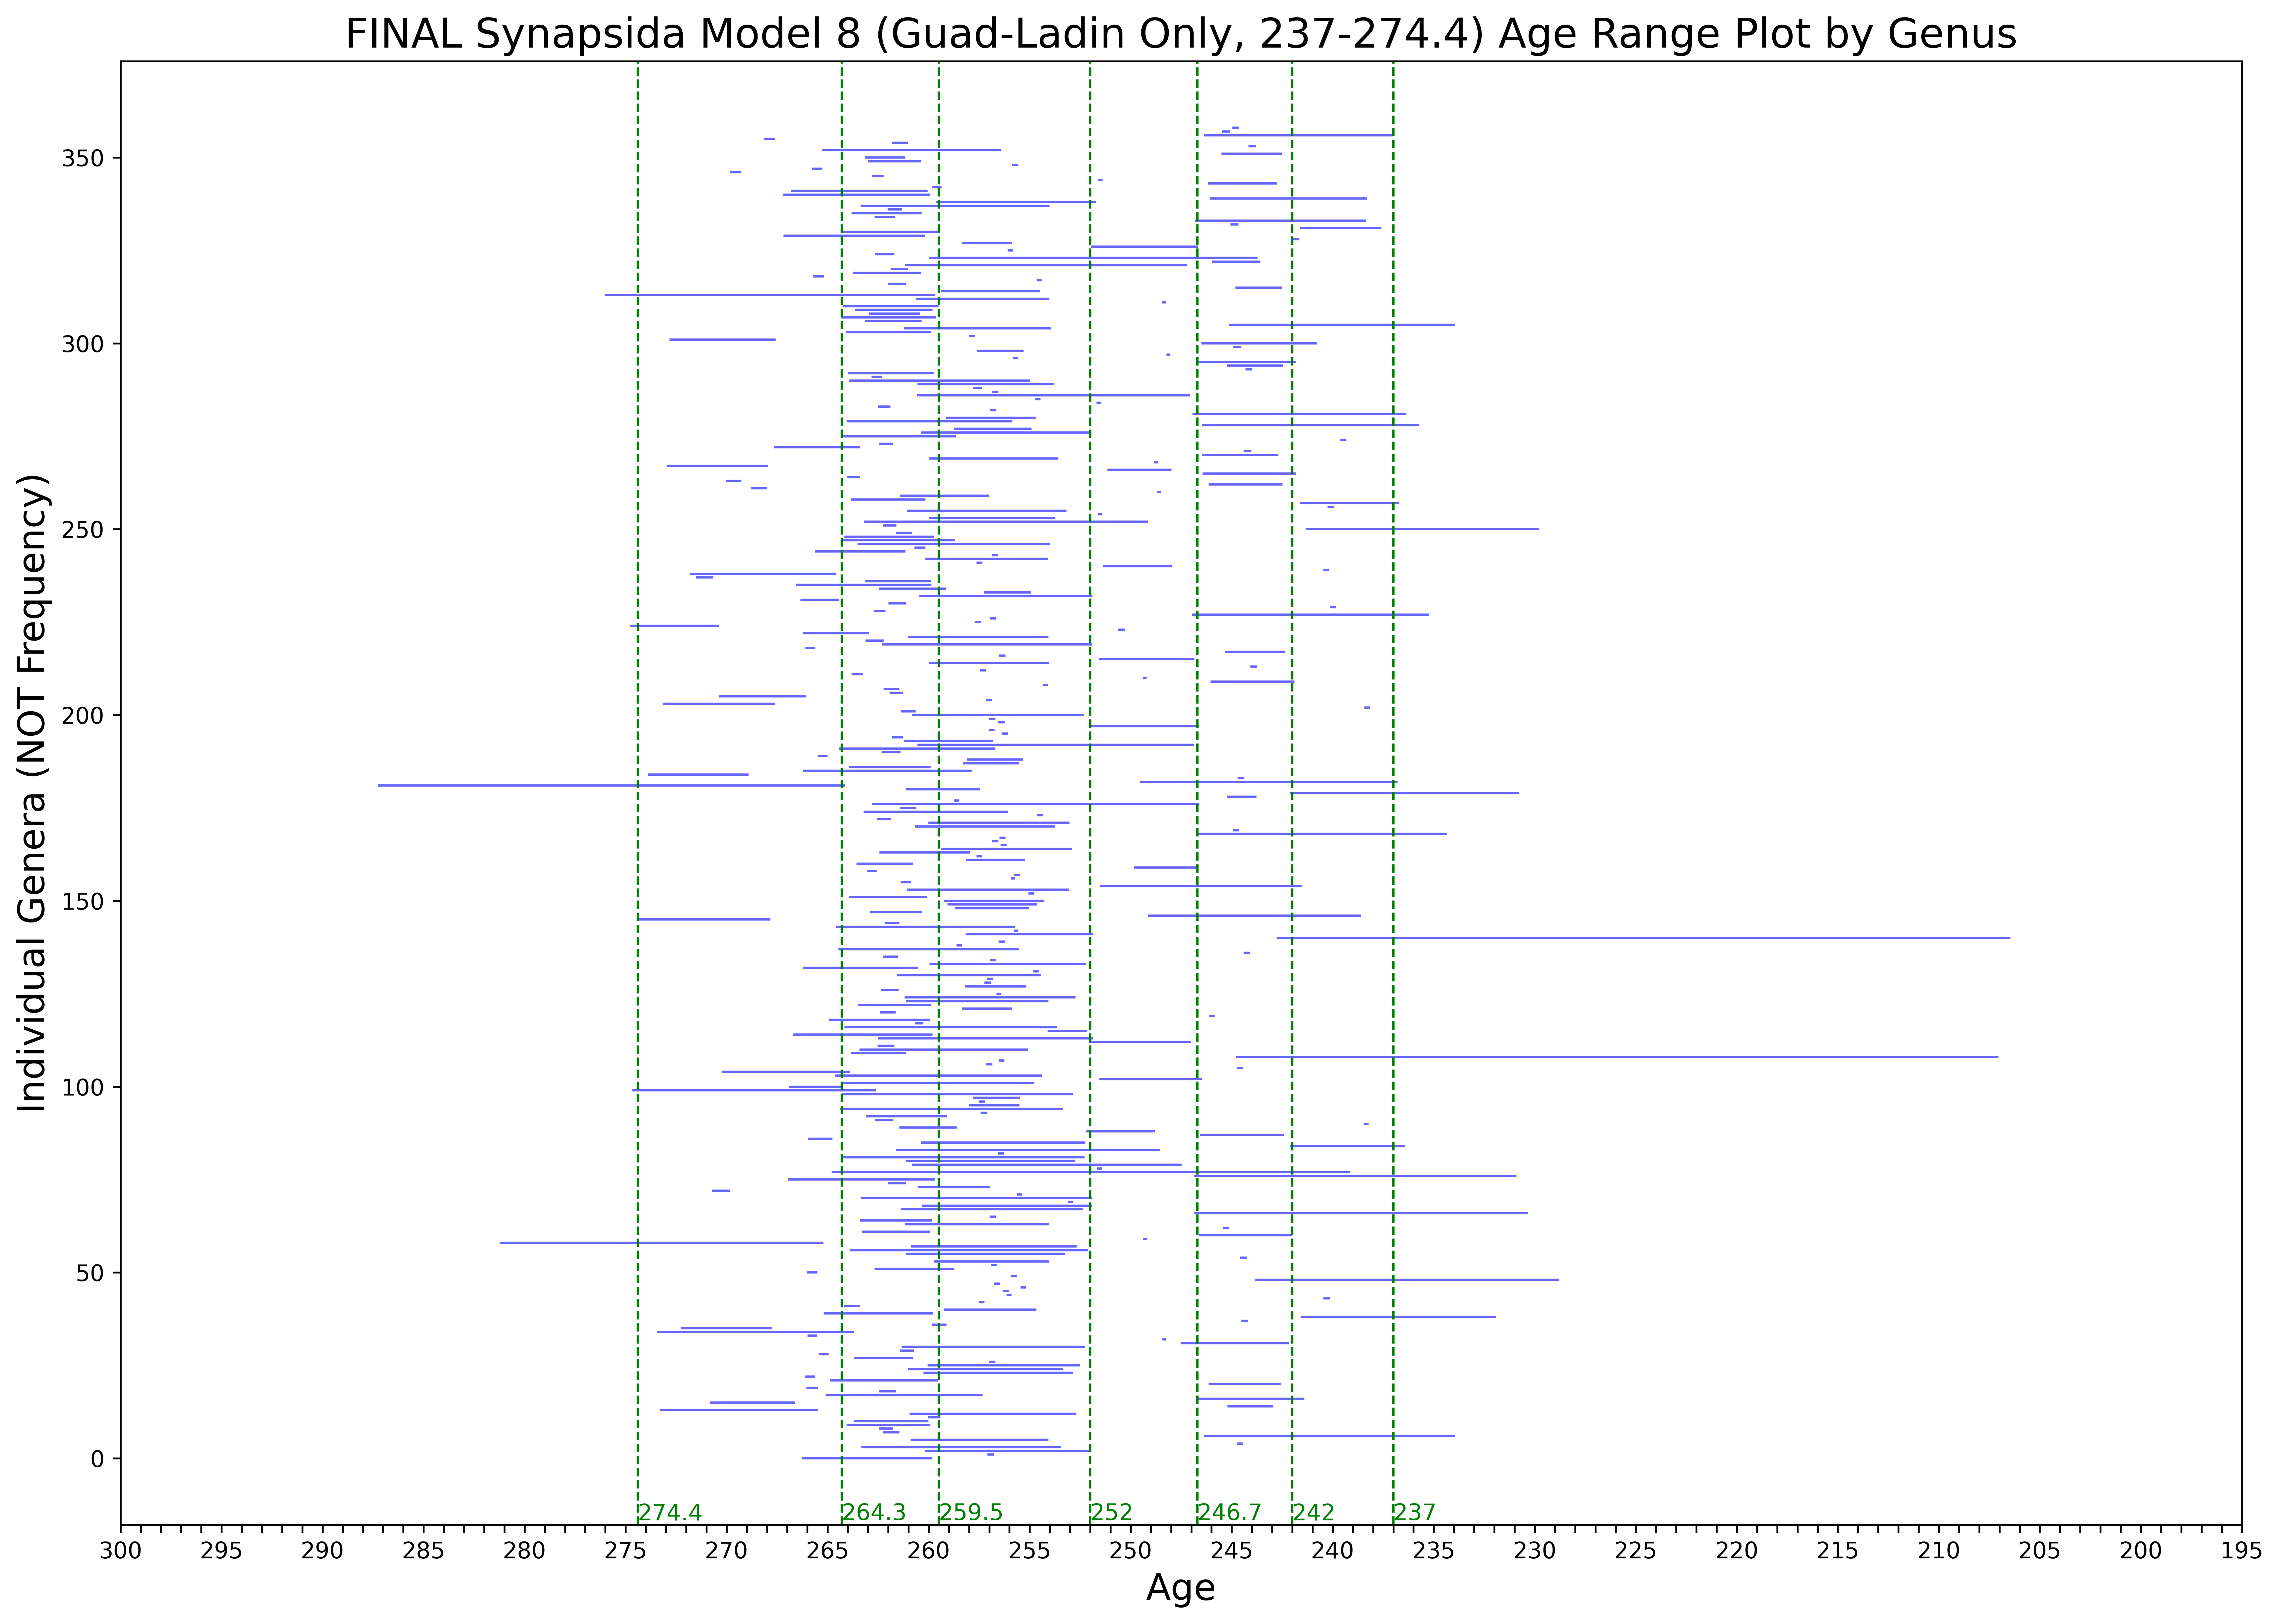

In [54]:
model_8_syn_range_plot = range_plot(model_8_syn_nn_wi_gl_stage, "FINAL Synapsida Model 8 (Guad-Ladin Only, 237-274.4)")
model_8_syn_range_plot.savefig("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/ts_te_plots/synapsida_model_8_age_rage_plot_GLFILT_FINAL.pdf")
model_8_syn_range_plot

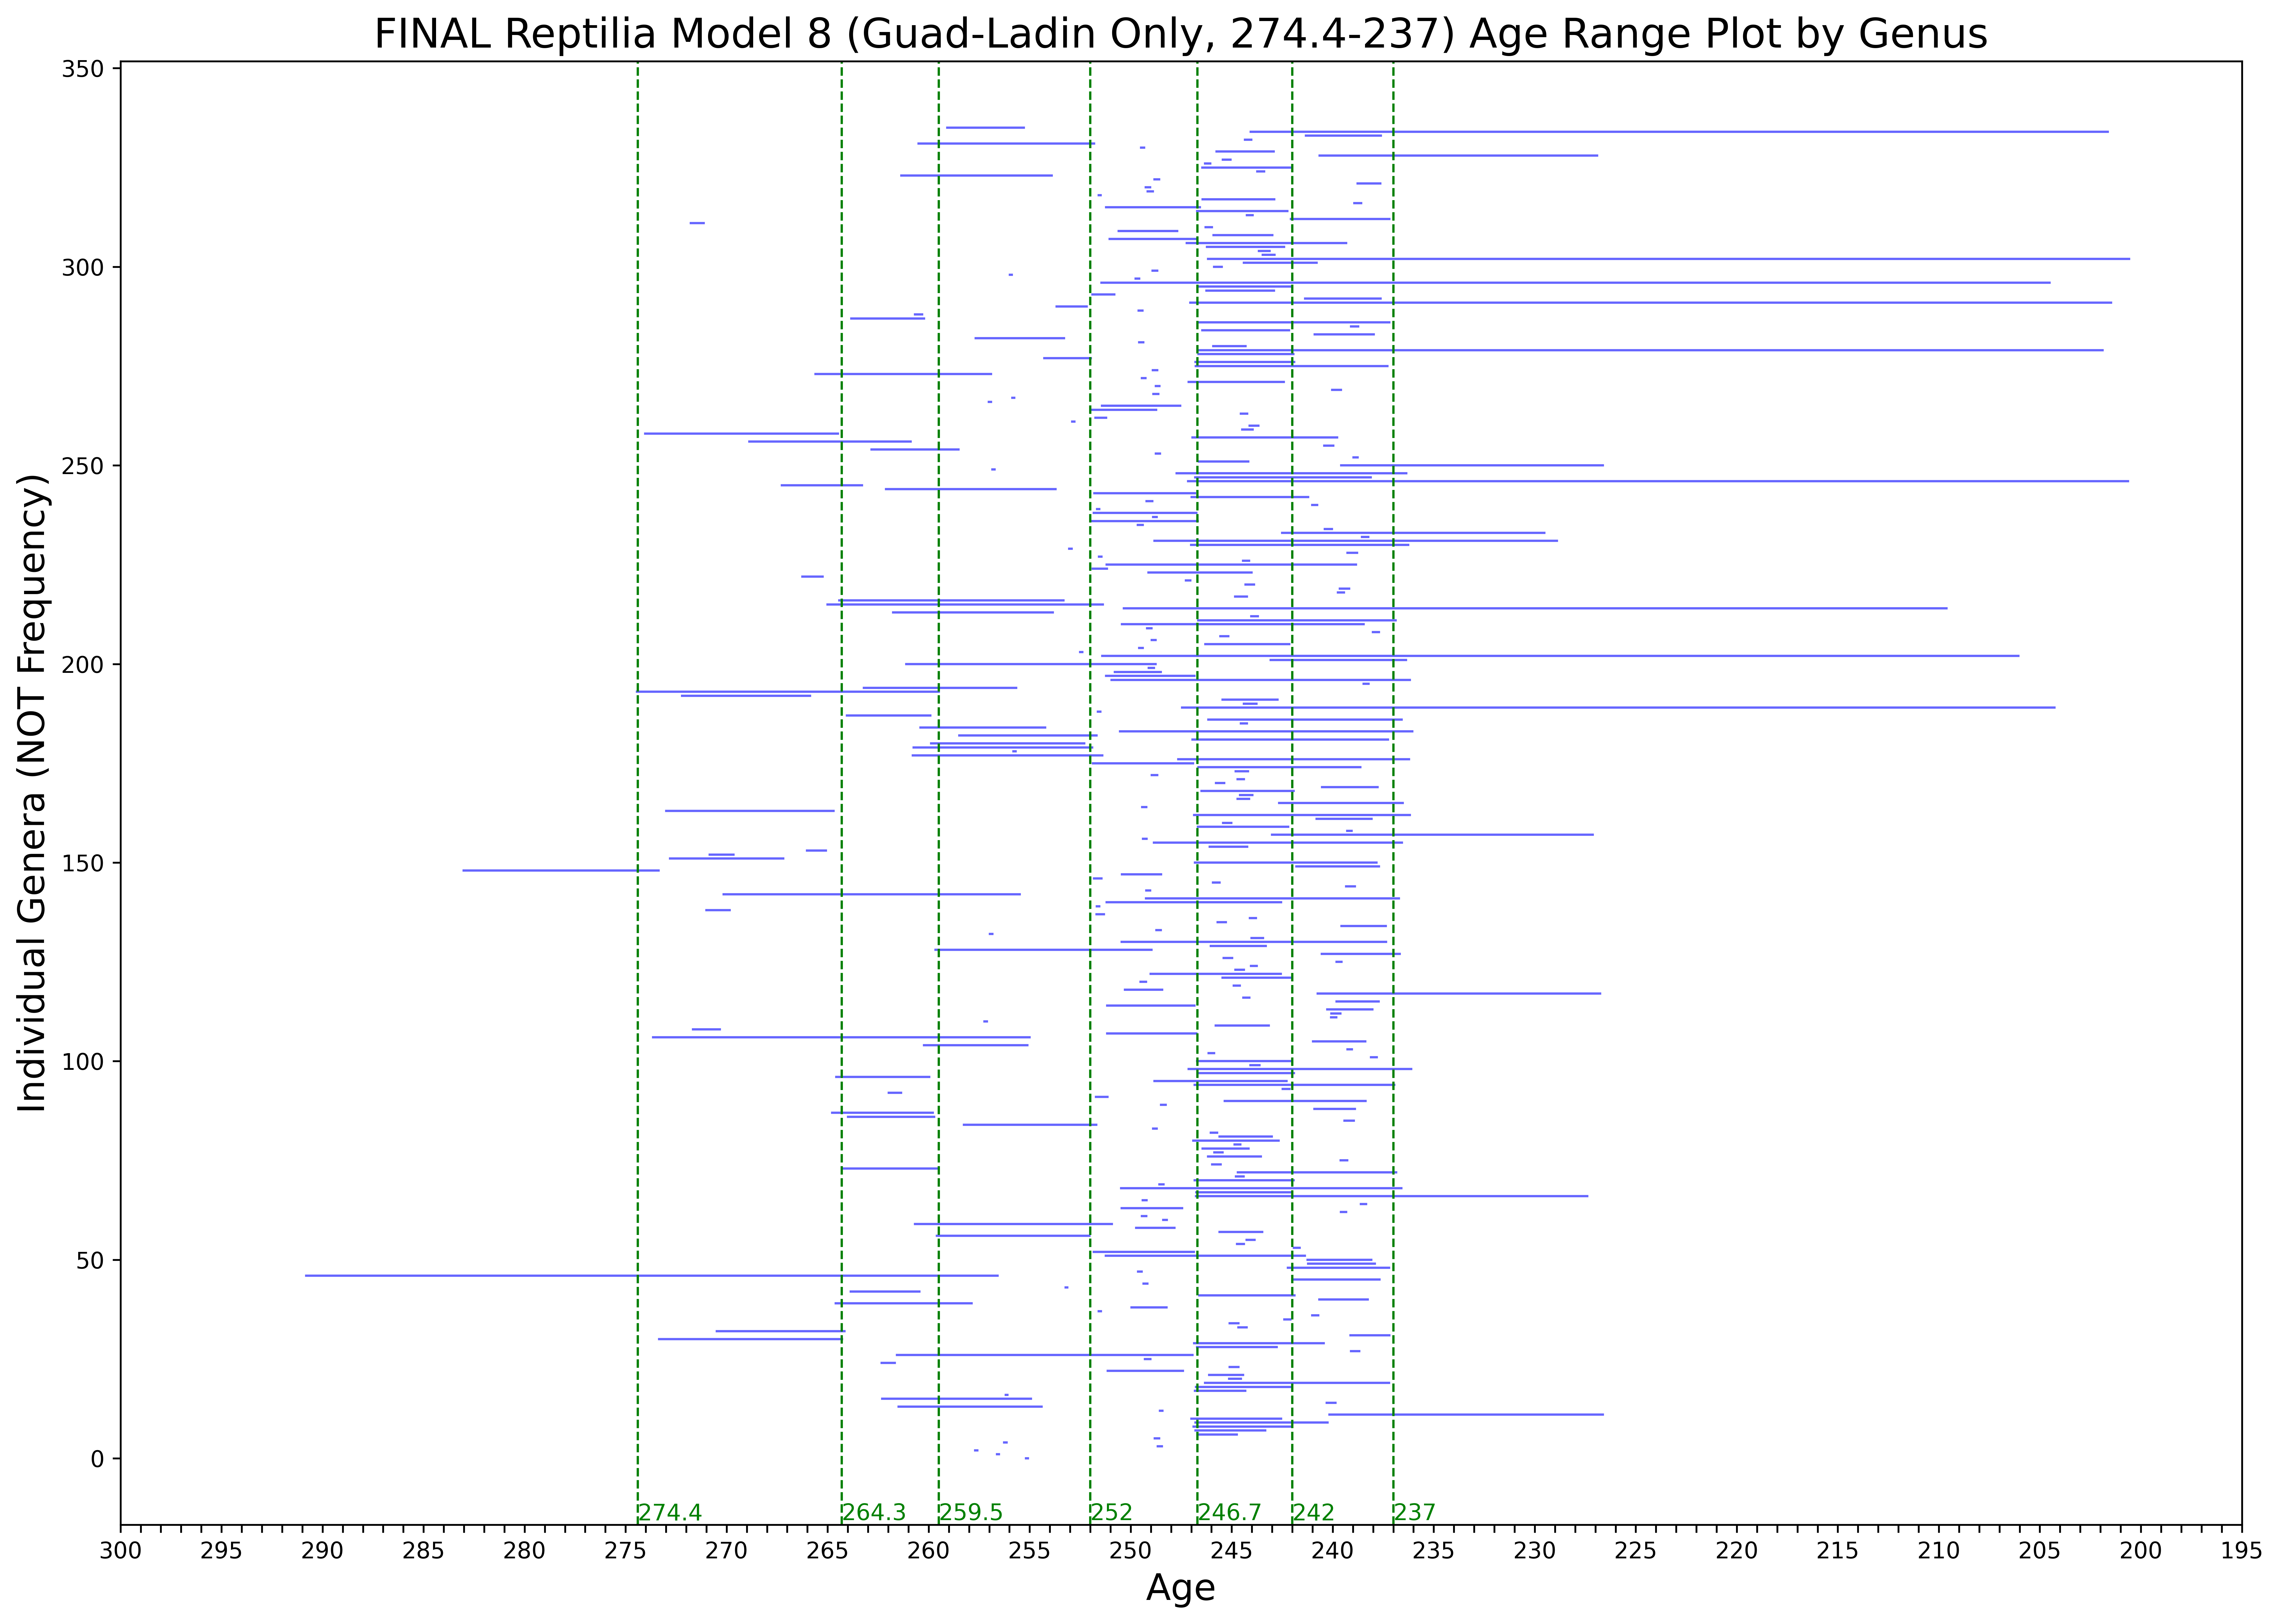

In [ ]:
model_8_rep_range_plot = range_plot(model_8_rep_nn_wi_gl_stage, "FINAL Reptilia Model 8 (Guad-Ladin Only, 274.4-237)")
model_8_rep_range_plot.savefig("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/ts_te_plots/reptilia_all_model_8_age_rage_plot_GLFILT_FINAL.pdf")
model_8_rep_range_plot

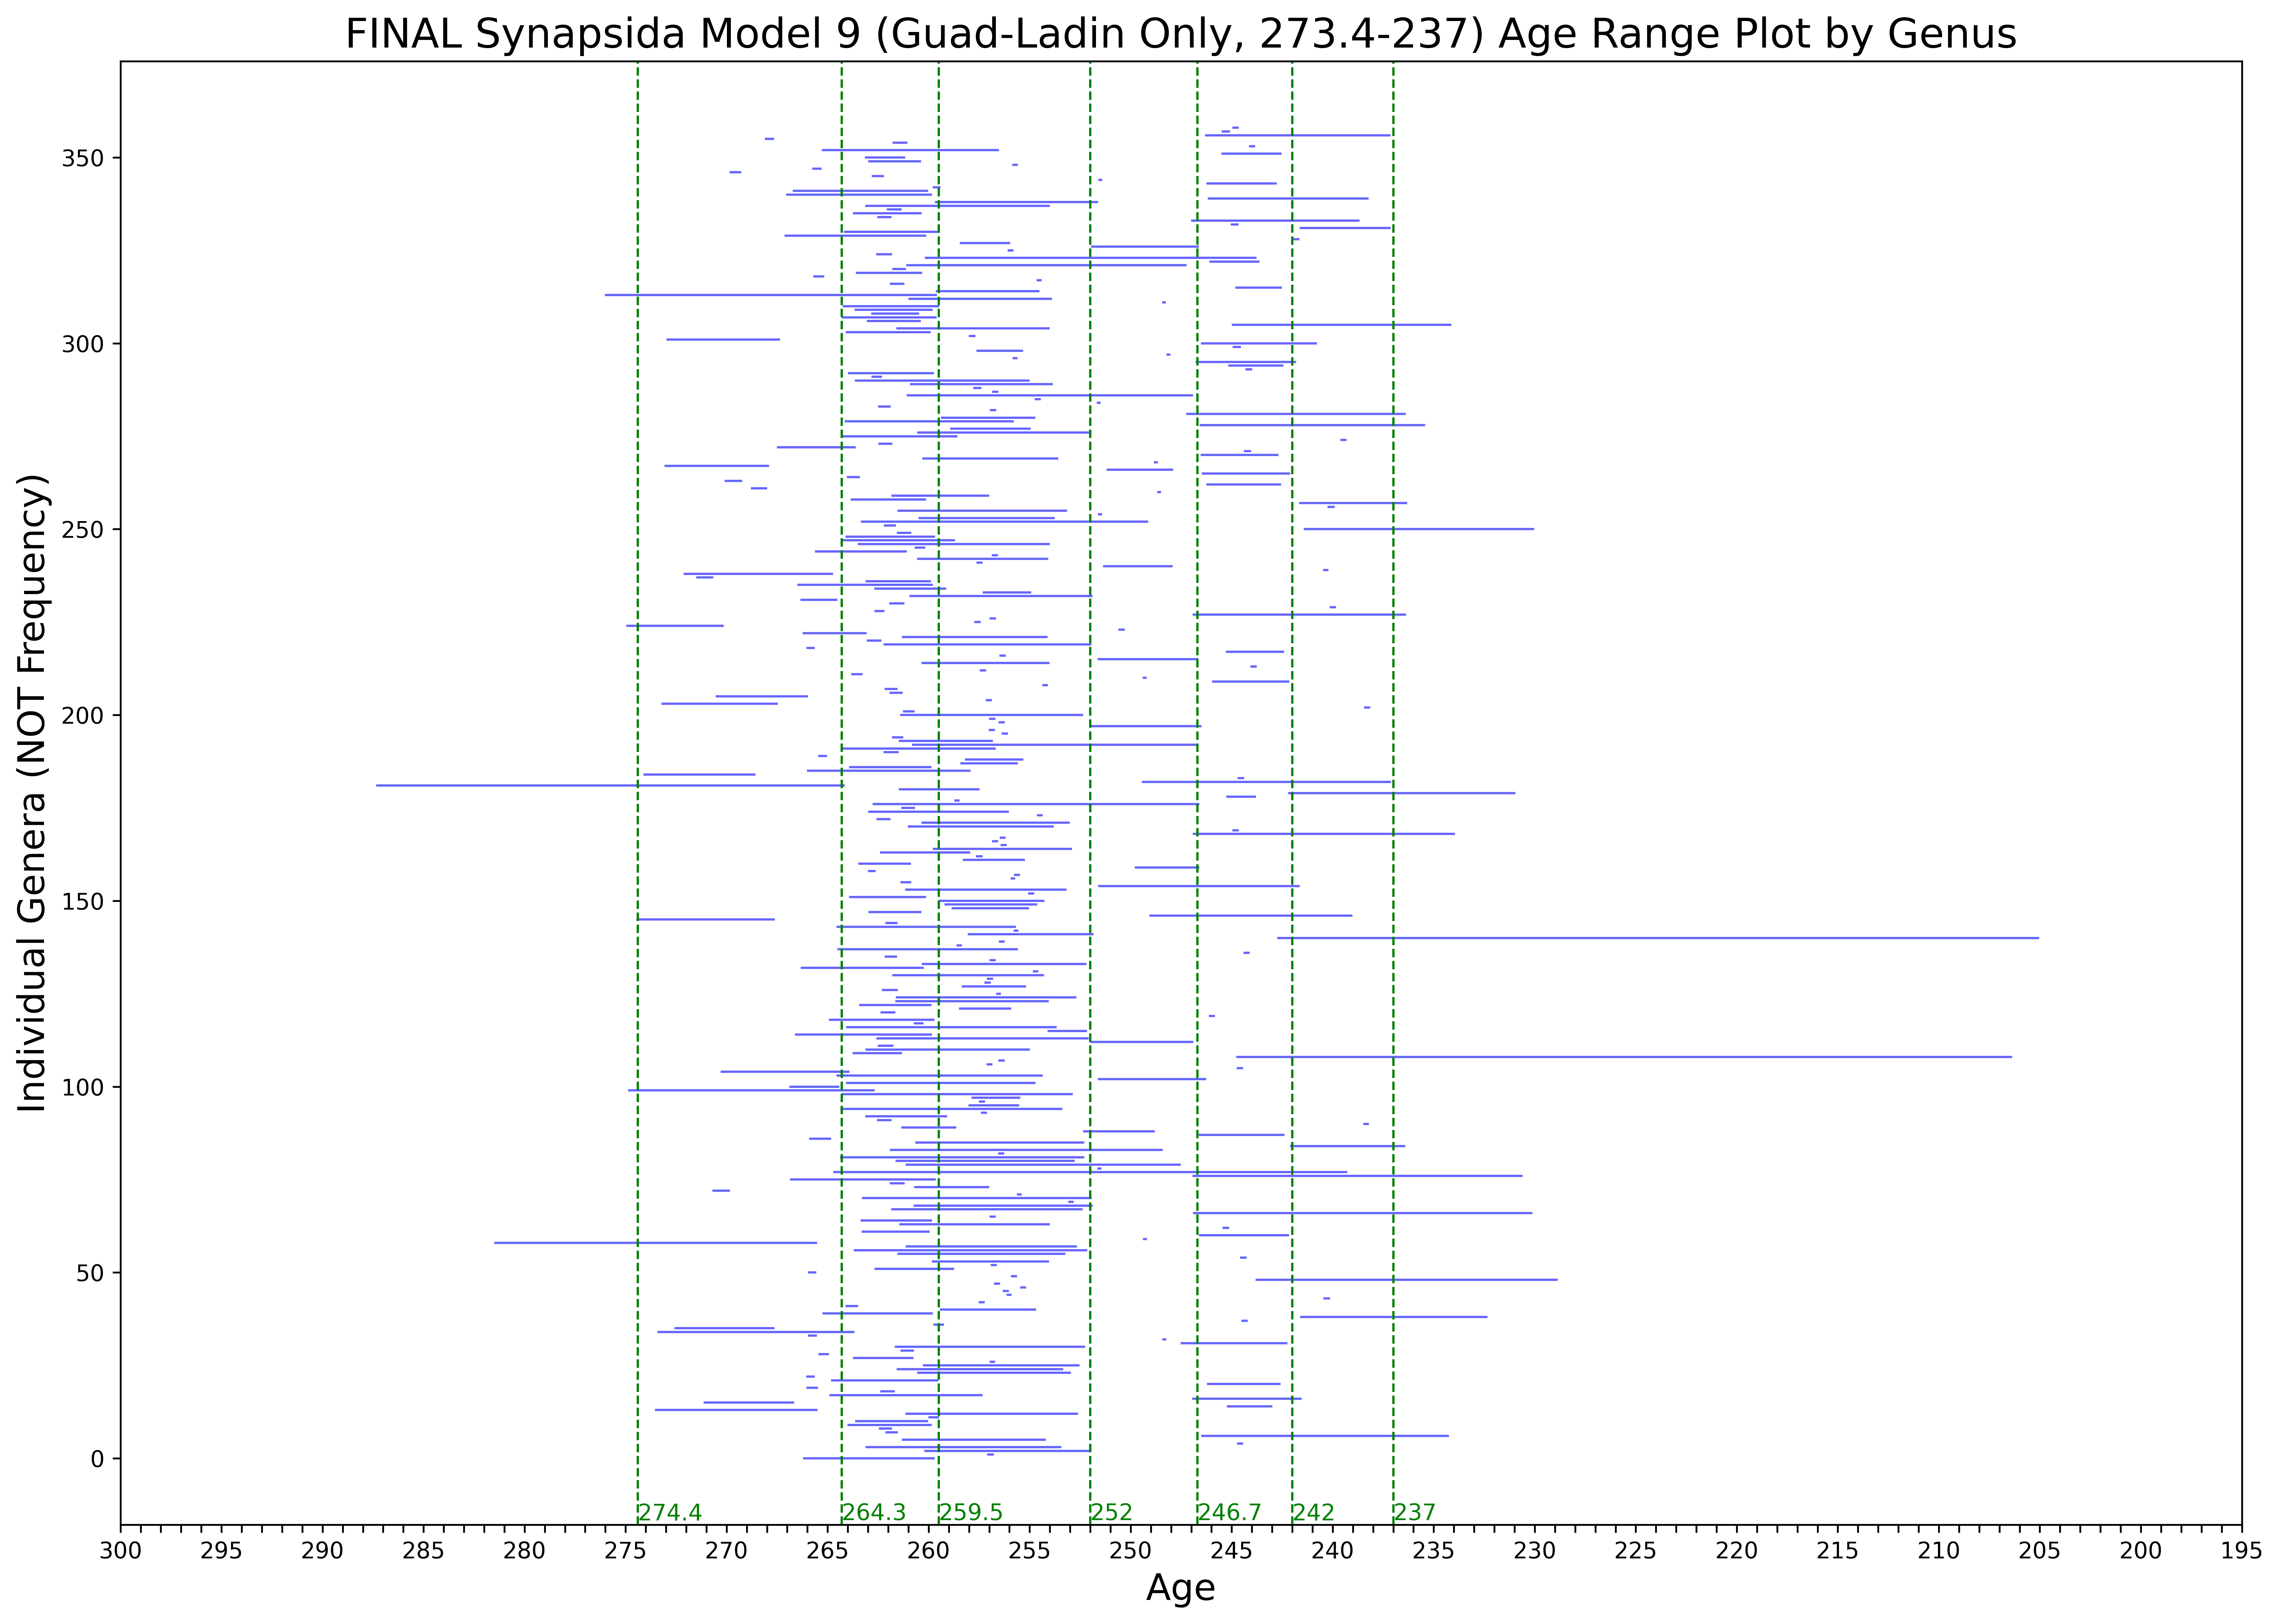

In [58]:
model_9_syn_range_plot = range_plot(model_9_syn_nn_wi_gl_stage, "FINAL Synapsida Model 9 (Guad-Ladin Only, 273.4-237)")
model_9_syn_range_plot.savefig("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/ts_te_plots/synapsida_model_9_age_rage_plot_GLFILT_FINAL.pdf")
model_9_syn_range_plot

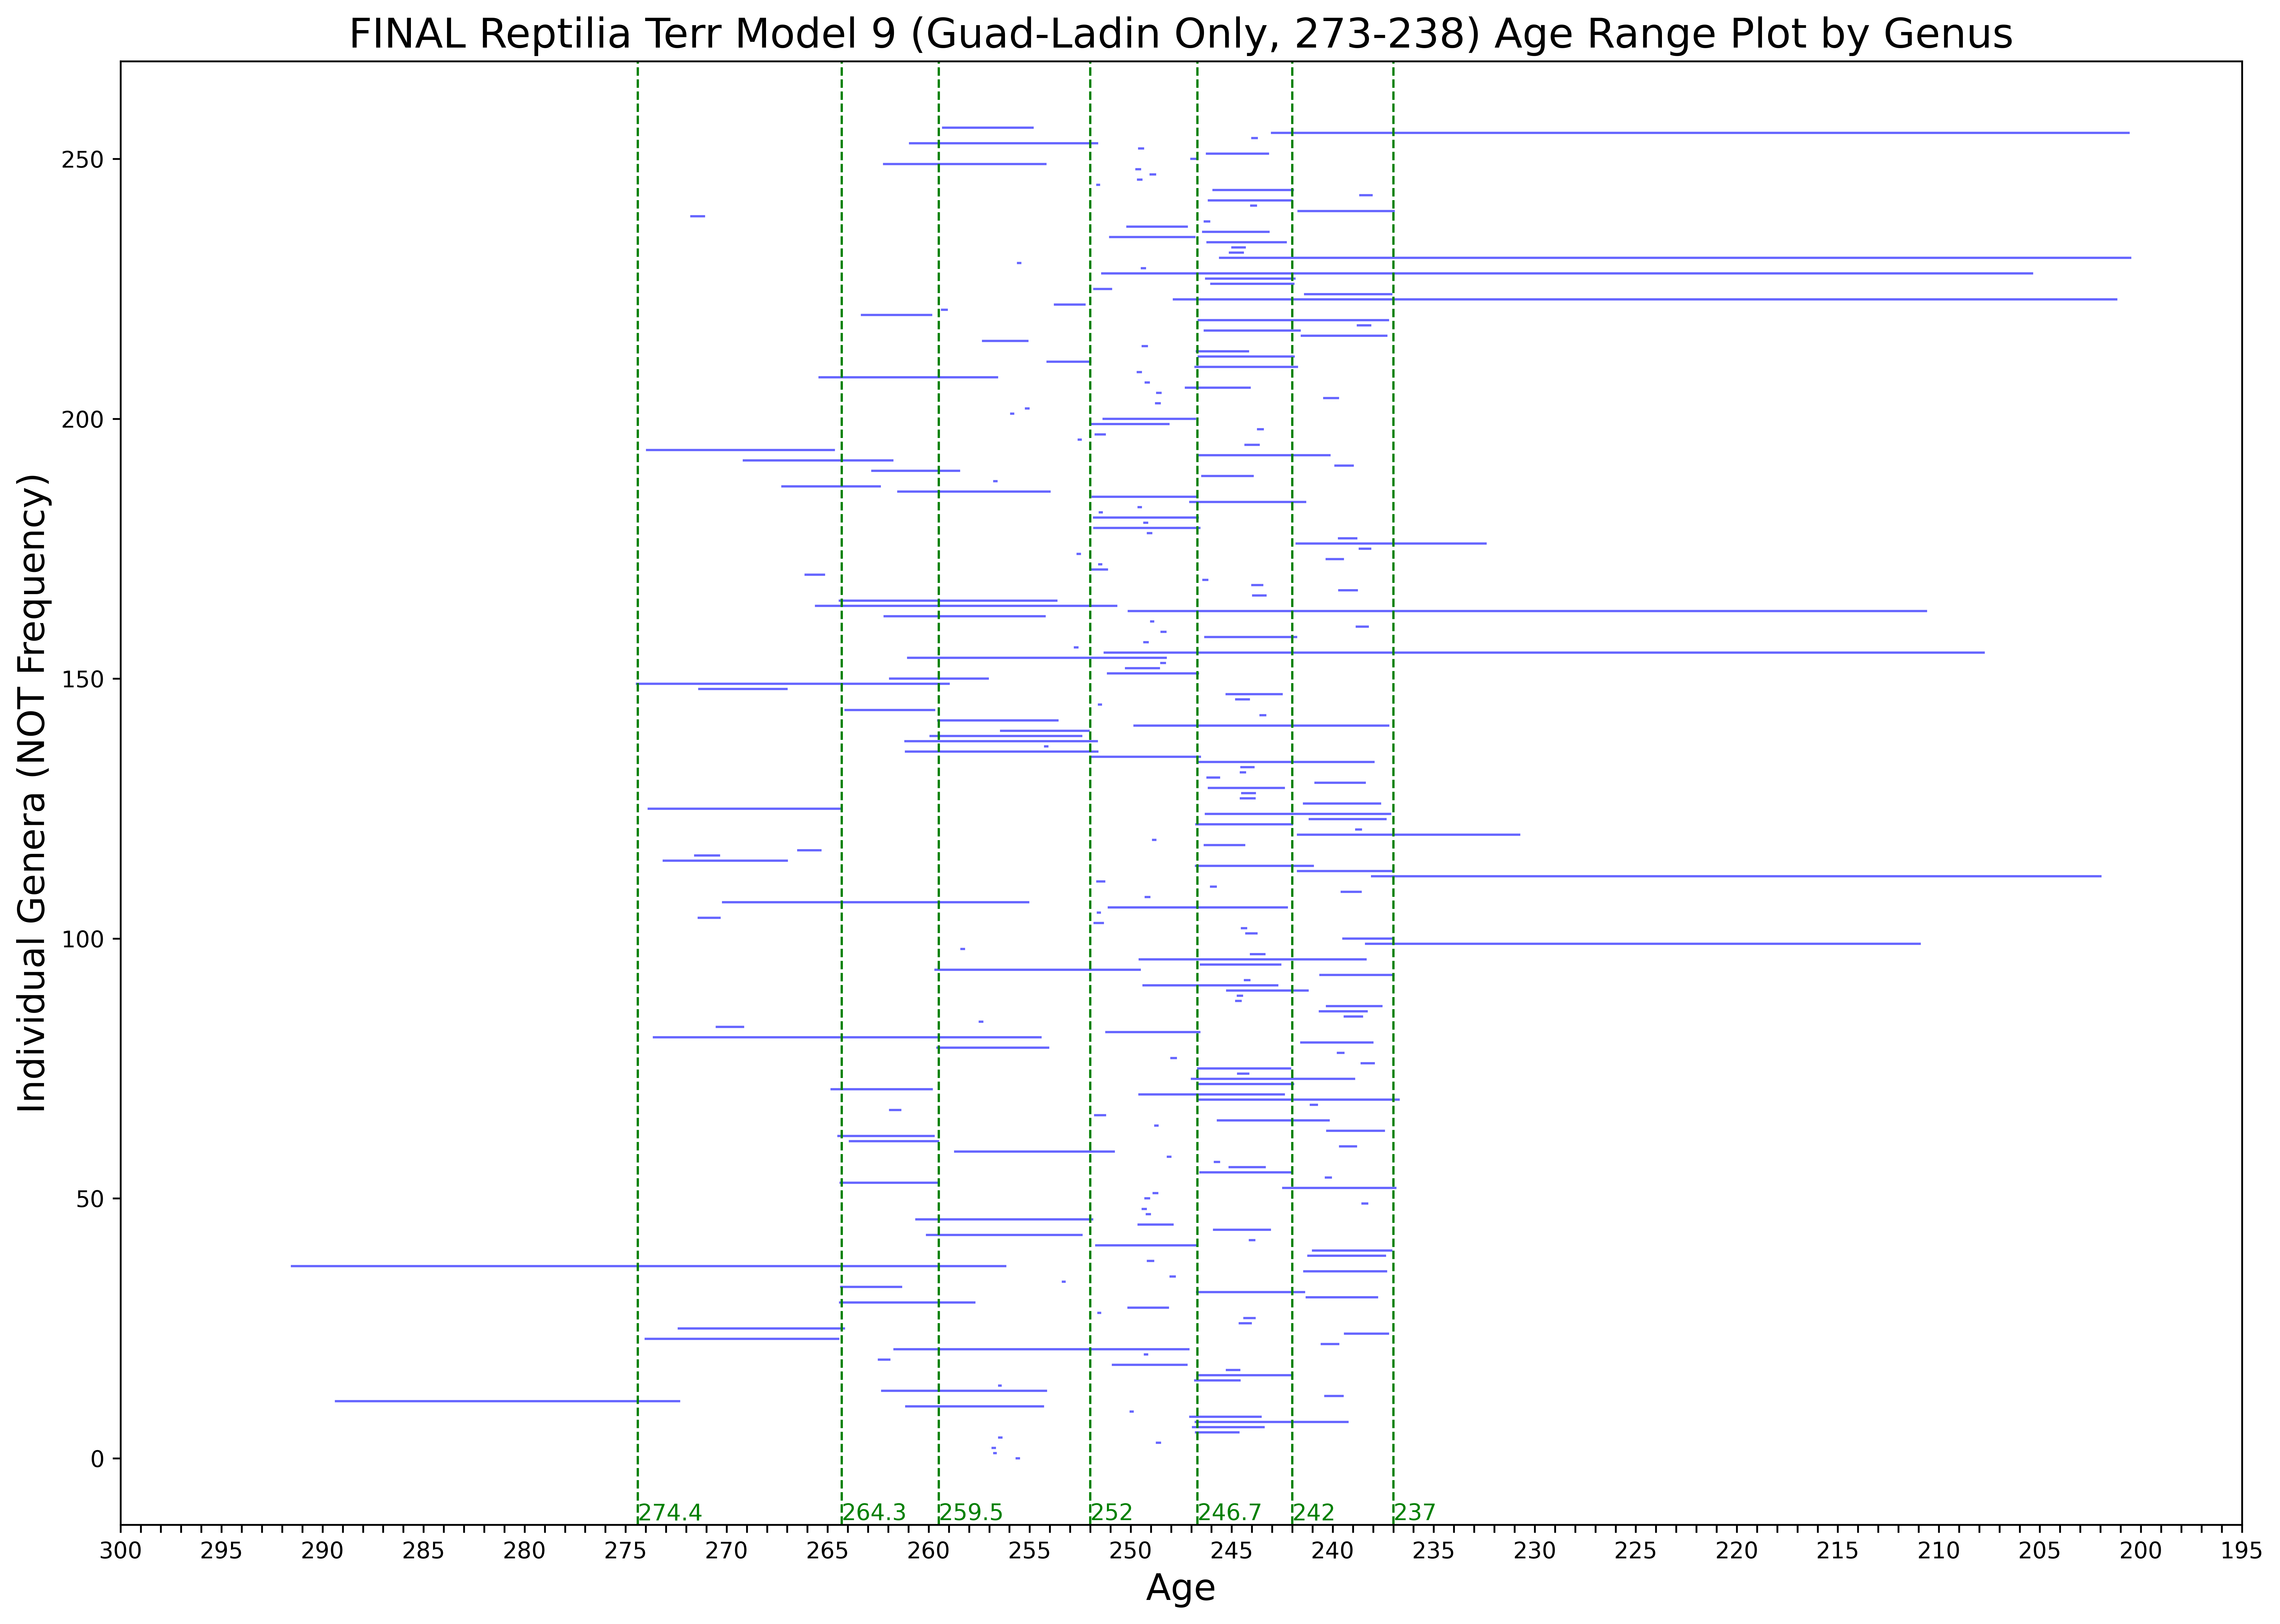

In [57]:
model_9_rep_terr_range_plot = range_plot(model_9_rep_terr_nn_wi_gl_stage, "FINAL Reptilia Terr Model 9 (Guad-Ladin Only, 273-238)")
model_9_rep_terr_range_plot.savefig("C:/Users/SimoesLabAdmin/Documents/pt_diversity_rates/updated_occurrence_analyses/data/causality_data/ts_te_plots/reptilia_terr_model_9_age_range_plot_GLFILT_FINAL.pdf")
model_9_rep_terr_range_plot